In [1]:
import pandas as pd

문제 정의
농구 선수의 경기 기록을 바탕으로, 그 선수의 포지션을 예측하라
데이터 수집

In [2]:
# 데이터를 수집합니다
df = pd.read_csv("./dataset_0411.csv")

In [3]:
# 수집된 데이터 샘플을 확인합니다
df.head()

,user_id,pc_throttle,pc_brake,t-b,pc_steering,t-b-s,pc_speed,pc_lap_distance
0,1,0.656263,0,0.656263,0.001859,0.654404,15.9202,0.338890
1,1,0.656263,0,0.656263,0.001859,0.654404,15.9202,0.338890
2,1,0.656263,0,0.656263,0.001859,0.654404,16.2642,0.874889
3,1,0.656263,0,0.656263,0.001488,0.654775,16.6117,1.450100
4,1,0.656263,0,0.656263,0.001488,0.654775,16.6117,1.450100


In [4]:
# 현재 가지고 있는 데이터에서, 포지션의 갯수를 확인한다
df.user_id.value_counts()

1    412
2    361
Name: user_id, dtype: int64

데이터 시각화
데이터를 특징을 바탕으로 한 공간에 시각화함으로써,우리는 머신러닝 학습에 필요한 특징과 불필요한 특징을 쉽게 구분지을 수 있습니다.

Text(0.5, 1, 'Speed and Throttle-Break-Steering')

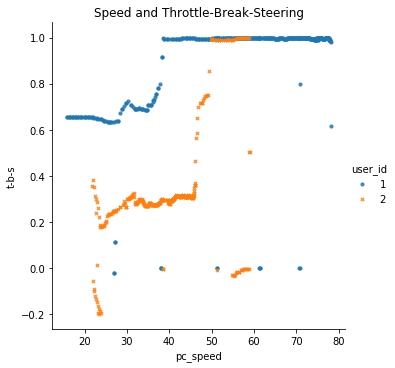

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 스틸, 2점슛 데이터 시각화
sns.lmplot('pc_speed', 't-b-s', data=df, fit_reg=False,  # x 축, y 축, 데이터, 라인 없음
           scatter_kws={"s": 10}, # 좌표 상의 점의 크기
           markers=["o", "x"],
           hue="user_id") # 예측값

# title
plt.title('Speed and Throttle-Break-Steering')

Text(0.5, 1, 'Distance and Speed')

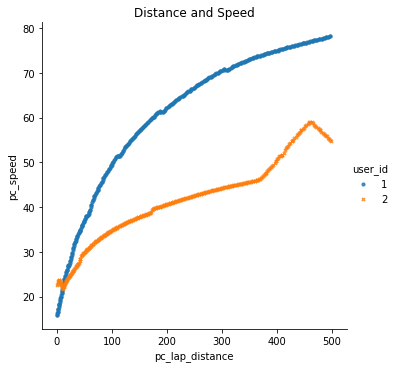

In [6]:
# 어시스트, 2점슛 데이터 시각화
sns.lmplot('pc_lap_distance', 'pc_speed', data=df, fit_reg=False,  # x 축, y 축, 데이터, 라인 없음
           scatter_kws={"s": 10}, # 좌표 상의 점의 크기
           markers=["o", "x"],
           hue="user_id") # 예측값

# title
plt.title('Distance and Speed')

Text(0.5, 1, 'Distance and Throttle-Break-Steering')

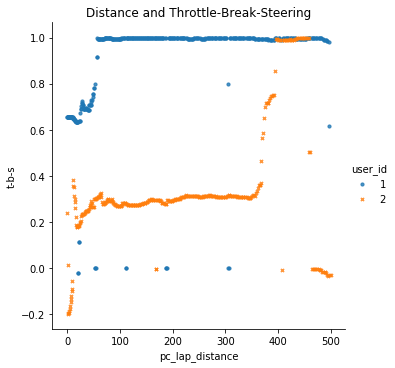

In [7]:
# 블로킹, 3점슛 데이터 시각화
sns.lmplot('pc_lap_distance', 't-b-s', data=df, fit_reg=False,  # x 축, y 축, 데이터, 라인 없음
           scatter_kws={"s": 10}, # 좌표 상의 점의 크기
           markers=["o", "x"],
           hue="user_id") # 예측값

# title
plt.title('Distance and Throttle-Break-Steering')

Text(0.5, 1, 'Speed and Throttle-Break-Steering')

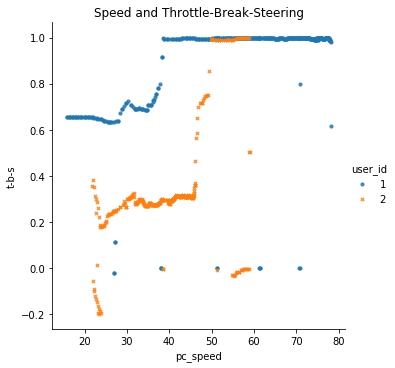

In [8]:
# 리바운드, 3점슛 데이터 시각화
sns.lmplot('pc_speed', 't-b-s', data=df, fit_reg=False,  # x 축, y 축, 데이터, 라인 없음
           scatter_kws={"s": 10}, # 좌표 상의 점의 크기
           markers=["o", "x"],
           hue="user_id") # 예측값

# title
plt.title('Speed and Throttle-Break-Steering')

데이터 다듬기

In [9]:
# 분별력이 없는 특징(feature)을 데이터에서 제거합니다
df.drop(['pc_throttle','pc_brake','t-b','pc_steering'], axis=1, inplace = True)

데이터 나누기 (학습 데이터, 테스트 데이터)

In [10]:
# sklearn의 train_test_split을 사용하면 라인 한줄로 손쉽게 데이터를 나눌 수 있다
from sklearn.model_selection import train_test_split

# 다듬어진 데이터에서 20%를 테스트 데이터로 분류합니다
train, test = train_test_split(df, test_size=0.2)

In [11]:
# 학습 데이터의 갯수를 확인합니다, 80개의 데이터가 있습니다.
train.shape[0]

618

In [12]:
# 테스트 데이터의 갯수를 확인합니다. 20개의 데이터가 있습니다.
test.shape[0]

155

다듬어진 데이터를 파일로 저장하기
다듬어진 데이터를 파일로 저장하여, 머신러닝 분류 알고리즘 실습 시에 사용하도록 하겠습니다.

In [13]:
import pickle
with open('./dataset_0411_train.pkl', 'wb') as train_data:
    pickle.dump(train, train_data)
    
with open('./dataset_0411_test.pkl', 'wb') as test_data:
    pickle.dump(test, test_data)